In [1]:
%cd /cephyr/users/felixnie/Alvis/NeuroCBIR/
# %cd /home/maia-user/NeuroCBIR/

/cephyr/users/felixnie/Alvis/NeuroCBIR


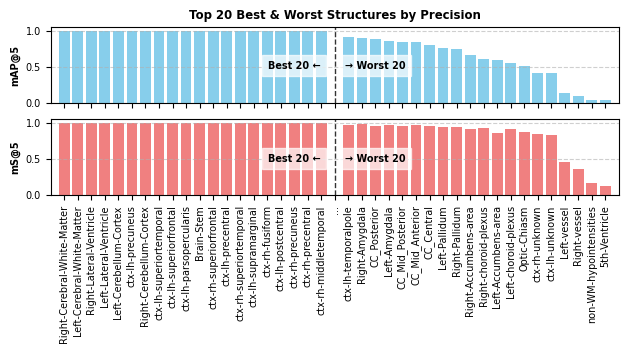

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Set plot style and font size for clarity
plt.style.use('default')
plt.rcParams.update({'font.size': 7})

only_show_top = 20

# Load metrics.json
with open("dev/data_private/results/region_brain/eval__d_32__m_02__lid_02__mid_02__pn_005/metrics.json", "r") as f:
    metrics = json.load(f)

# Extract precision and success at top_5
results = []
for structure, vals in metrics.items():
    top5 = vals["standard"]["top_5"]
    results.append({
        "structure": structure,
        "precision": top5["mAP@k"],
        "success": top5["success@k"],
    })

# Sort by precision
results_sorted = sorted(results, key=lambda x: x["precision"], reverse=True)

# Select top 20 and bottom 20
top20 = results_sorted[:only_show_top]
bottom20 = results_sorted[-only_show_top:]

# Insert a gap placeholder
gap_entry = {"structure": "...", "precision": np.nan, "success": np.nan}
subset = top20 + [gap_entry] + bottom20

# Extract for plotting
structures = [r["structure"] for r in subset]
precisions = [r["precision"] for r in subset]
successes = [r["success"] for r in subset]

# Convert cm → inches
cm = 1/2.54
fig, axes = plt.subplots(2, 1, figsize=(16*cm, 9*cm), sharex=True)

# Precision subplot
axes[0].bar(range(len(subset)), precisions, color="skyblue")
axes[0].set_ylabel("mAP@5", fontweight="bold")
axes[0].set_title("Top 20 Best & Worst Structures by Precision", fontweight="bold")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# Success subplot
axes[1].bar(range(len(subset)), successes, color="lightcoral")
axes[1].set_ylabel("mS@5", fontweight="bold")
axes[1].set_xticks(range(len(subset)))
axes[1].set_xticklabels(structures, rotation=90)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

# Add labels for groups
ymax0 = axes[0].get_ylim()[1]
ymax1 = axes[1].get_ylim()[1]

sep_index = len(top20)
for ax in axes:
    ax.axvline(sep_index, color="black", linestyle="--", alpha=0.8, linewidth=1)
    t1 = ax.text(only_show_top-3, ymax0*0.45, f"Best {only_show_top} ←", ha="center", fontweight="bold")
    t1.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='white'))
    t2 = ax.text(len(subset)-only_show_top+2, ymax0*0.45, f"→ Worst {only_show_top}", ha="center", fontweight="bold")
    t2.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='white'))
    ax.set_xlim([-1,only_show_top*2+1])
    ax.set_ylim([0, 1.05])

plt.tight_layout()
# plt.savefig(f"figures/top_20_structures.pdf", format='pdf', bbox_inches='tight')
plt.show()

/local/tmp.5685192/ipykernel_3674279/2064799001.py:77: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)


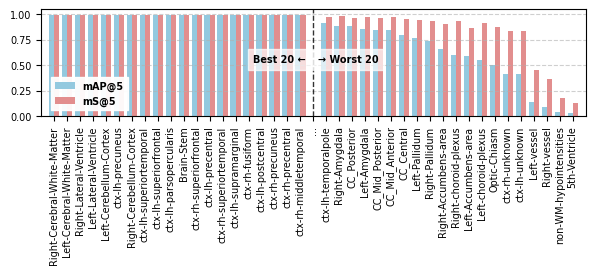

In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline

# Set plot style and font size for clarity
plt.style.use('default')
plt.rcParams.update({'font.size': 7})

only_show_top = 20

# Load metrics.json
with open("dev/data_private/results/region_brain/eval__d_32__m_02__lid_02__mid_02__pn_005/metrics.json", "r") as f:
    metrics = json.load(f)

# Extract precision and success at top_5
results = []
for structure, vals in metrics.items():
    top5 = vals["standard"]["top_5"]
    results.append({
        "structure": structure,
        "precision": top5["mAP@k"],
        "success": top5["success@k"],
    })

# Sort by precision
results_sorted = sorted(results, key=lambda x: x["precision"], reverse=True)

# Select top 20 and bottom 20
top20 = results_sorted[:only_show_top]
bottom20 = results_sorted[-only_show_top:]

# Insert a gap placeholder
gap_entry = {"structure": "...", "precision": np.nan, "success": np.nan}
subset = top20 + [gap_entry] + bottom20

# Convert to DataFrame (wide format)
df = pd.DataFrame(subset)

# Reshape to long format for seaborn
df_long = df.melt(id_vars="structure", 
                  value_vars=["precision", "success"], 
                  var_name="metric", 
                  value_name="score")

# Convert cm → inches
cm = 1/2.54
fig, ax = plt.subplots(figsize=(15*cm, 7*cm))

# Seaborn barplot with hue
b = sns.barplot(data=df_long, x="structure", y="score", hue="metric", ax=ax, 
            palette={"precision": "skyblue", "success": "lightcoral"})

# Get current legend
leg = ax.legend(
    loc='lower left',         # or "outside" with bbox_to_anchor
    bbox_to_anchor=(0.01, 0.01),
    title=None,
    framealpha=0.95,
    # frameon=False
    edgecolor="w",
    fancybox=False
)

# Make legend labels bold
label_text = ["mAP@5", "mS@5"]
for text, label in zip(leg.get_texts(), label_text):
    text.set_fontweight("bold")
    text.set_text(label)

# Axis labels and formatting
ax.set_ylabel("", fontweight="bold")
ax.set_xlabel("")
# ax.set_title("Top 20 Best & Worst Structures by Precision & Success", fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Add separator line between best and worst groups
sep_index = len(top20)
ax.axvline(sep_index, color="black", linestyle="--", alpha=0.8, linewidth=1)

# Add group labels
ymax = ax.get_ylim()[1]
t1 = ax.text(only_show_top-2.6, ymax*0.5, f"Best {only_show_top} ←", ha="center", fontweight="bold")
t1.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='white'))
t2 = ax.text(len(subset)-only_show_top+1.7, ymax*0.5, f"→ Worst {only_show_top}", ha="center", fontweight="bold")
t2.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='white'))

# Adjust axis limits
ax.set_xlim([-1, only_show_top*2+1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
# plt.savefig(f"figures/top_20_structures.pdf", format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()


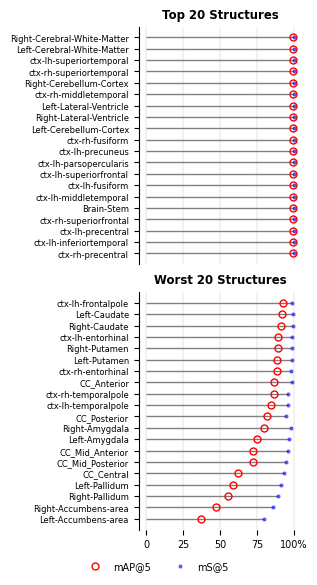

In [5]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set plot style and font size for clarity
plt.style.use('default')
plt.rcParams.update({'font.size': 7})

# Load metrics.json
with open("dev/data_private/results/region_brain/eval__d_32__m_02__lid_02__mid_02__pn_005/metrics.json", "r") as f:
    metrics = json.load(f)
    
# Load data/labels.csv
labels_df = pd.read_csv("data/labels.csv")

# keep only structures in metrics that are labels_df.Use == 1
labels_df = labels_df[labels_df["Use"] == 1]
metrics = {k: v for k, v in metrics.items() if k in labels_df["LabelName"].values}

# Extract top_5 metrics
results = []
for structure, vals in metrics.items():
    top1 = vals["bias"]["top_1"]["partition"][0]
    top5 = vals["bias"]["top_5"]["partition"][0]
    partition = top5["partition"]
    if partition == "train":
        raise ValueError("Training partition found in evaluation metrics.")
        continue
    results.append({
        "structure": structure,
        "mAP@5": top5["mAP@k"],
        "mS@1": top1["success@k"],
        "mS@5": top5["success@k"],
    })

# Sort by mAP
results_sorted = sorted(results, key=lambda x: x["mAP@5"], reverse=True)

only_show_top = 20
top20 = results_sorted[:only_show_top]
bottom20 = results_sorted[-only_show_top:]

# Convert to DataFrame and assign y positions
df_top = pd.DataFrame(top20)
df_top["y_pos"] = range(len(df_top))

df_bottom = pd.DataFrame(bottom20)
df_bottom["y_pos"] = range(len(df_bottom))

# Plot
cm = 1/2.54
fig, axes = plt.subplots(2, 1, figsize=(8*cm, 15*cm), sharex=True)

def plot_panel(ax, df, title):
    for _, row in df.iterrows():
        # Line
        ax.hlines(
            y=row["y_pos"],
            xmin=0,
            xmax=max(row["mAP@5"], row["mS@5"]) * 100,
            colors="grey",
            linestyles="solid",
            linewidth=1
        )
        # mAP: red empty circle
        ax.plot(
            row["mAP@5"] * 100, row["y_pos"],
            "o", markerfacecolor="none", markeredgecolor="red",
            markersize=5, label="mAP@5"
        )
        # mS: blue filled circle
        ax.plot(
            row["mS@5"] * 100, row["y_pos"],
            "o", markerfacecolor="blue", markeredgecolor="blue",
            markersize=2, alpha=0.5, label="mS@5"
        )

    # Customize y-axis
    ax.set_yticks(df["y_pos"])
    ax.set_yticklabels(df["structure"], fontsize=6)
    ax.invert_yaxis()
    ax.set_ylabel("")
    ax.grid(axis="x", color="0.95", linestyle="solid", linewidth=1.5)
    ax.set_title(title, fontweight="bold")

# Top panel
plot_panel(axes[0], df_top, f"Top {only_show_top} Structures")

# Bottom panel
plot_panel(axes[1], df_bottom, f"Worst {only_show_top} Structures")

# X-axis settings
axes[1].set_xticks([0, 25, 50, 75, 100])
axes[1].set_xticklabels(["0", "25", "50", "75", "100%"])
axes[0].xaxis.set_ticks_position('none')
# axes[1].xaxis.set_ticks_position('none')
# axes[1].set_xlabel("Score (%)")

# Clean up spines
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

# Legend (single, outside)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[-2:], labels[-2:], 
           loc="lower center", bbox_to_anchor=(0.5, 0.016),
           ncol=2, frameon=False)
    
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("dev/figures/top_20_structures.pdf", format="pdf", bbox_inches="tight", pad_inches=0)
plt.show()


In [6]:
# Table with all results
import pandas as pd

# Create a DataFrame with the results
df_results = pd.DataFrame(results_sorted)

# To percentages and round to 1 decimal place
df_results["mAP@5"] = (df_results["mAP@5"] * 100).round(1)
df_results["mS@1"] = (df_results["mS@1"] * 100).round(1)
df_results["mS@5"] = (df_results["mS@5"] * 100).round(1)

# The table is too long, instead of 4 coulmns, do 8 columns, 2 sets of 4 columns
df_results = pd.concat([
    df_results.iloc[:52].reset_index(drop=True),
    df_results.iloc[52:].reset_index(drop=True)
], axis=1)  


# Save the DataFrame to a CSV file
df_results.to_csv("dev/figures/all_structures.csv", index=False)

# get latex table
latex_table = df_results.to_latex(index=False,
                                  formatters={"name": str.upper},
                                  float_format="{:.1f}".format,
                                  )
with open("dev/figures/all_structures.tex", "w") as f:
    f.write(latex_table)

**FIGURE: EXAMPLE OF INPUT - GT FOR BRAIN STRUCTURES**

In [3]:
from dev.preprocessing.load_dataset import SubCorBatDataset
import pandas as pd
import os
import numpy as np
%matplotlib inline

### Input data
# Path to dataset
DATA_PATH = "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/"
load_ds_path = DATA_PATH + "batched_adni/"
# Files to load/save extension
extension = ".npz"
# Pretrained weights for the VAE
ckpt_vae_path = ""#"./data/pretrained_models/autoencoder_puglisi.pth"
# Pretrained weights for the Discriminator
ckpt_dis_path = ""#"./data/pretrained_models/ckpt_dis_.pth"
# Preparing image for using as input of the VAE
target_shape = [1, 160, 224, 160] # Desired shape: [1, 160, 224, 160]

# Load metadata
index_ds = pd.read_csv(os.path.join(DATA_PATH,"original/dataset_index.csv"))
clinical_ds = pd.read_csv(os.path.join(DATA_PATH,"combined_metadata.csv"))
metadata = pd.merge(index_ds, clinical_ds, on="GUID", how="inner") # Merge on the 'GUID' column
print(f"METADATA: Original rows: {len(metadata)}")

# First, ensure empty strings are treated as NaN
metadata['subject'].replace('', pd.NA, inplace=True)

# Then drop rows where subject is NaN
metadata = metadata.dropna(subset=['subject'])

# Optional: reset index
metadata = metadata.reset_index(drop=True)
print(f"METADATA: Remaining rows: {len(metadata)}") # Check result

# Load labels

# Training configuration
batch_files = sorted(metadata["batch_file"].unique())

# Load labels and bounding boxes
labels_df = pd.read_csv("data/labels.csv")
bb_df = pd.read_csv("data/bounding_boxes.csv")
labels_bb_df = pd.merge(labels_df, bb_df, on="LabelName", how="inner") # Merge on the 'GUID' column

batch_files = batch_files[-4:-3] # To only load ABLI
print(batch_files)

from dev.preprocessing.load_dataset import SingleStructDataset
dataset = SingleStructDataset(metadata, batch_files, labels_bb_df, target_struct_name="Left-Hippocampus")

guids = np.array(dataset.guids)

METADATA: Original rows: 26685
METADATA: Remaining rows: 26685
['/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/original/batched_aibl/batch_0002.npz']


In [4]:
df = []
for guid in guids:
    subject_id = dataset.metadata.query(f"GUID == '{guid}'")[["subject"]].values[0, 0]
    df.append([guid, subject_id])
df = pd.DataFrame(df, columns=['GUID', 'subject'])
counts = df.groupby('subject').count().sort_values(by="GUID",ascending=False)
print()


N guid in subject: 4


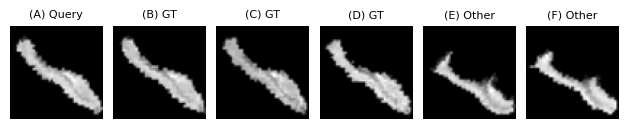

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch
%matplotlib inline

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

# Pick one subject (query subject)
idx = 1
subject_id = counts.iloc[idx].name
subject_guids = df.query(f"subject == '{subject_id}'").GUID.to_list()
print(f"N guid in subject: {len(subject_guids)}")

# Get dataset indices for this subject
i_subs = [np.where(guids == g)[0][0] for g in subject_guids]

# Pick another subject (different from query)
other_subject_id = counts.iloc[idx+3].name
other_subject_guids = df.query(f"subject == '{other_subject_id}'").GUID.to_list()
i_subs_other = [np.where(guids == g)[0][0] for g in other_subject_guids]

# --- Select which samples to plot ---
# Query = first scan of subject
query_idx = i_subs[0]

# Ground truth = next 3 scans of same subject (if available)
gt_indices = i_subs[1:4]

# Other = 2 scans from another subject
other_indices = i_subs_other[:2]

# Final sequence of indices
plot_indices = [query_idx] + gt_indices + other_indices

# --- Plot axial slices only ---
cm = 1/2.54
fig, axes = plt.subplots(1, 6, figsize=(16*cm, 5*cm))

structs = []
for ax, i_sub in zip(axes, plot_indices):
    sample = dataset[i_sub]
    struct = sample["image"][0]  # shape [D, H, W]

    # find best axial slice (z axis)
    z_idx = struct.shape[0] // 2
    axial = struct[z_idx, :, :].cpu()

    ax.imshow(axial, cmap="gray")
    ax.axis("off")

    # label query vs GT vs other
    subj = dataset.metadata.query(f"GUID == '{sample['GUID']}'")[["subject"]].values[0, 0]
    ax.set_title(f"{sample['GUID']}\nsubj {subj}", fontsize=7)

    structs.append(axial.cpu().numpy().copy())

axes[0].set_title("(A) Query", fontsize=8)
axes[1].set_title("(B) GT", fontsize=8)
axes[2].set_title("(C) GT", fontsize=8)
axes[3].set_title("(D) GT", fontsize=8)
    
axes[4].set_title("(E) Other", fontsize=8)
axes[5].set_title("(F) Other", fontsize=8)

plt.tight_layout()
# plt.savefig(f"figures/example_structures_sample.pdf", format='pdf', bbox_inches='tight')
plt.show()


**FIGURE: EXAMPLE OF INPUT - GT FOR WHOLE BRAIN**

In [6]:
if "dataset" in locals():
    del dataset

from dev.preprocessing.load_dataset import LookupNPZDataset
import pandas as pd
import os
import numpy as np

### Input data
# Path to dataset
DATA_PATH = "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/"
load_ds_path = DATA_PATH + "batched_adni/"
# Files to load/save extension
extension = ".npz"
# Pretrained weights for the VAE
ckpt_vae_path = ""#"./data/pretrained_models/autoencoder_puglisi.pth"
# Pretrained weights for the Discriminator
ckpt_dis_path = ""#"./data/pretrained_models/ckpt_dis_.pth"
# Preparing image for using as input of the VAE
target_shape = [1, 160, 224, 160] # Desired shape: [1, 160, 224, 160]

# Load metadata
index_ds = pd.read_csv(os.path.join(DATA_PATH,"original/dataset_index.csv"))
clinical_ds = pd.read_csv(os.path.join(DATA_PATH,"combined_metadata.csv"))
metadata = pd.merge(index_ds, clinical_ds, on="GUID", how="inner") # Merge on the 'GUID' column
print(f"METADATA: Original rows: {len(metadata)}")

# First, ensure empty strings are treated as NaN
metadata['subject'].replace('', pd.NA, inplace=True)

# Then drop rows where subject is NaN
metadata = metadata.dropna(subset=['subject'])

# Optional: reset index
metadata = metadata.reset_index(drop=True)
print(f"METADATA: Remaining rows: {len(metadata)}") # Check result

# Load labels

# Training configuration
batch_files = sorted(metadata["batch_file"].unique())
batch_files = batch_files[-4:-3] # To only load ABLI
batch_file = batch_files[0]
print(batch_files)

from dev.preprocessing.load_dataset import SingleStructDataset
dataset = LookupNPZDataset(metadata, batch_file=batch_file, use_segmentation=False)

guids = np.array(dataset.guids)

METADATA: Original rows: 26685
METADATA: Remaining rows: 26685
['/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/original/batched_aibl/batch_0002.npz']


In [7]:
df = []
for guid in guids:
    subject_id = dataset.metadata.query(f"GUID == '{guid}'")[["subject"]].values[0, 0]
    df.append([guid, subject_id])
df = pd.DataFrame(df, columns=['GUID', 'subject'])
counts = df.groupby('subject').count().sort_values(by="GUID",ascending=False)
print()

N guid in subject: 4


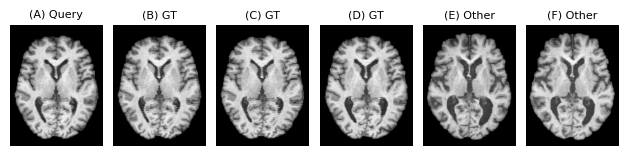

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch
%matplotlib inline

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

# Pick one subject (query subject)
idx = 1
subject_id = counts.iloc[idx].name
subject_guids = df.query(f"subject == '{subject_id}'").GUID.to_list()
print(f"N guid in subject: {len(subject_guids)}")

# Get dataset indices for this subject
i_subs = [np.where(guids == g)[0][0] for g in subject_guids]

# Pick another subject (different from query)
other_subject_id = counts.iloc[idx+3].name
other_subject_guids = df.query(f"subject == '{other_subject_id}'").GUID.to_list()
i_subs_other = [np.where(guids == g)[0][0] for g in other_subject_guids]

# --- Select which samples to plot ---
# Query = first scan of subject
query_idx = i_subs[0]

# Ground truth = next 3 scans of same subject (if available)
gt_indices = i_subs[1:4]

# Other = 2 scans from another subject
other_indices = i_subs_other[:2]

# Final sequence of indices
plot_indices = [query_idx] + gt_indices + other_indices

# --- Plot axial slices only ---
cm = 1/2.54
fig, axes = plt.subplots(1, 6, figsize=(16*cm, 5*cm))

brains = []
for ax, i_sub in zip(axes, plot_indices):
    sample = dataset[i_sub]
    brain = sample["image"][0]  # shape [D, H, W]

    # find best axial slice (z axis)
    # z_profile = struct.sum(axis=(1, 2))
    # z_max = torch.argmax(z_profile).item()
    # axial = struct[z_max, :, :].cpu()

    z_idx = brain.shape[1] // 2
    axial = brain[:, z_idx, :].cpu()

    ax.imshow(axial.T.flip(0), cmap="gray") #, vmin=0, vmax=0.8)
    ax.axis("off")

    # label query vs GT vs other
    subj = dataset.metadata.query(f"GUID == '{sample['GUID']}'")[["subject"]].values[0, 0]
    ax.set_title(f"{sample['GUID']}\nsubj {subj} {z_idx}", fontsize=7)

    brains.append(axial.T.flip(0).cpu().numpy().copy())

axes[0].set_title("(A) Query", fontsize=8)
axes[1].set_title("(B) GT", fontsize=8)
axes[2].set_title("(C) GT", fontsize=8)
axes[3].set_title("(D) GT", fontsize=8)
axes[4].set_title("(E) Other", fontsize=8)
axes[5].set_title("(F) Other", fontsize=8)

plt.tight_layout()
# plt.savefig(f"figures/example_brain_sample.pdf", format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()


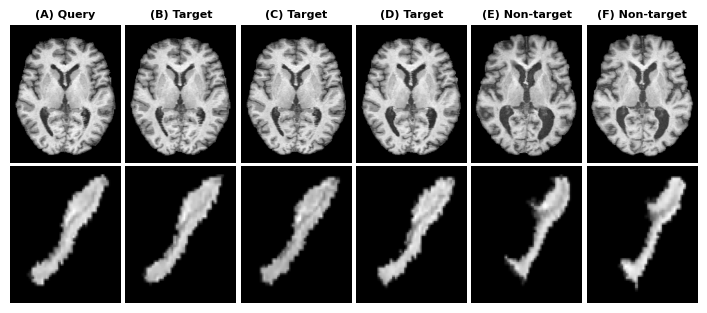

In [9]:
plt.style.use('default')
plt.rcParams.update({'font.size': 7})

# --- Plot axial slices only ---
cm = 1/2.54
fig, axes = plt.subplots(2, 6, figsize=(18*cm, 8*cm))

for i, (brain, region) in enumerate(zip(brains, structs)):
    axes[0][i].imshow(brain, cmap="gray") #, vmin=0, vmax=0.8)
    axes[1][i].imshow(np.pad(np.flip(region.T,axis=0), 5), cmap="gray")
    axes[0][i].axis("off")
    axes[1][i].axis("off")
    axes[0][i].set_aspect('auto')
    axes[1][i].set_aspect('auto')

axes[0][0].set_title("(A) Query", fontweight="bold", fontsize=8)
axes[0][1].set_title("(B) Target", fontweight="bold", fontsize=8)
axes[0][2].set_title("(C) Target", fontweight="bold", fontsize=8)
axes[0][3].set_title("(D) Target", fontweight="bold", fontsize=8)
axes[0][4].set_title("(E) Non-target", fontweight="bold", fontsize=8)
axes[0][5].set_title("(F) Non-target", fontweight="bold", fontsize=8)


plt.tight_layout()
plt.subplots_adjust(wspace=0.04, hspace=0.02)
# plt.savefig(f"figures/example_brain_region_sample.pdf", format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

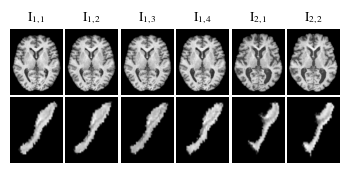

In [24]:
plt.style.use('default')
plt.rcParams.update({'font.size': 8})

plt.rcParams["font.family"] = "Nimbus Roman"
plt.rcParams["mathtext.rm"] = "Nimbus Roman"
plt.rcParams["mathtext.fontset"] = "stix"

# --- Plot axial slices only ---
cm = 1/2.54
fig, axes = plt.subplots(2, 6, figsize=(9*cm, 4.5*cm))


for i, (brain, region) in enumerate(zip(brains, structs)):
    axes[0][i].imshow(brain, cmap="gray") #, vmin=0, vmax=0.8)
    axes[1][i].imshow(np.pad(np.flip(region.T,axis=0), 5), cmap="gray")
    axes[0][i].axis("off")
    axes[1][i].axis("off")
    axes[0][i].set_aspect('auto')
    axes[1][i].set_aspect('auto')

axes[0][0].set_title(r"$\mathrm{I_{1,1}}$", fontweight="bold")
axes[0][1].set_title(r"$\mathrm{I_{1,2}}$", fontweight="bold")
axes[0][2].set_title(r"$\mathrm{I_{1,3}}$", fontweight="bold")
axes[0][3].set_title(r"$\mathrm{I_{1,4}}$", fontweight="bold")
axes[0][4].set_title(r"$\mathrm{I_{2,1}}$", fontweight="bold")
axes[0][5].set_title(r"$\mathrm{I_{2,2}}$", fontweight="bold")


plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.04)
plt.savefig(f"dev/figures/example_brain_region_sample.pdf", format='pdf', 
dpi=600,  # increase for higher-resolution embedded images
bbox_inches='tight', pad_inches=0)
plt.show()

In [78]:
region.min()

0.0

In [13]:
import matplotlib.font_manager as fm

# List all available fonts
for font in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if "Times" in font or "Times New Roman" in font:
        print(font)


In [12]:
import matplotlib
matplotlib.font_manager._rebuild()


AttributeError: module 'matplotlib.font_manager' has no attribute '_rebuild'

In [15]:
!ls /usr/share/fonts/


abattis-cantarell  dejavu  urw-base35


In [16]:
!apt install texlive texlive-latex-extra dvipng cm-super

Users aren't allowed to modify the OS. Please see homepage for https://www.c3se.chalmers.se on how to access and install software
